# 의사결정나무 모델

In [2]:
import pandas as pd 
df = pd.read_csv("data/ending_club_preprocessed2.csv")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("=" * 60)
print("로드 완료")
print("=" * 60)

로드 완료


## 의사결정 나무 

In [4]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

### 모델 전처리

In [5]:
# 데이터 로드 
y= df["target"] # target
X = df.drop(columns=["target"]) # 설명 변수 
# ((y == 1).sum()) / len(y) # 부도율 20% 


# 2) 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# 컬럼 구분 

num_cols  = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"수치형: {len(num_cols)}개\n{num_cols}\n")
print(f"범주형: {len(cat_cols)}개\n{cat_cols}")

수치형: 59개
['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'mths_since_rcnt_il', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',

In [7]:
# test data로 결측 처리 수치형 
# dti 
X_train["dti"] = X_train.groupby("grade")["dti"].transform(
    lambda x: x.fillna(x.median())
)

train_dit_medi = X_train.groupby("grade")["dti"].median()

X_test["dti"] = X_test["dti"].fillna(X_test["grade"].map(train_dit_medi))

# 신용 조회, 
cols = [
'mths_since_last_delinq',
'mths_since_last_record',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_rcnt_il', 
'mths_since_recent_inq', 
'mths_since_recent_bc'
]
for col in cols:
    max_val = X_train[col].max()
    X_train[col] = X_train[col].fillna(max_val + 1) 
    X_test[col] = X_test[col].fillna(max_val + 1) 


## mo_sin_old_il_acct 설명 가장 오래된 할부 계좌 이후 경과 월수
## 최대값 +1 
max_t_1 = X_train["mo_sin_old_il_acct"].max()
X_train["mo_sin_old_il_acct"] = X_train["mo_sin_old_il_acct"].fillna(max_t_1 + 1) 
X_test["mo_sin_old_il_acct"] =  X_test["mo_sin_old_il_acct"].fillna(max_t_1 + 1) 

# pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
## 중앙값으로 채우기 
medi_dlq = X_train["pct_tl_nvr_dlq"].median()
X_train["pct_tl_nvr_dlq"] = X_train["pct_tl_nvr_dlq"].fillna(medi_dlq)
X_test["pct_tl_nvr_dlq"] = X_test["pct_tl_nvr_dlq"].fillna(medi_dlq)

In [8]:
null_train = X_train.isnull().sum()
print(null_train[null_train>0])

null_test = X_test.isnull().sum()
print(null_test[null_test>0])

Series([], dtype: int64)
Series([], dtype: int64)


In [9]:
# 파이프 라인 생성 
# 수치형 파이프 라인 
num_pipeline = Pipeline([
])

# 범주형 파이프 라인: 원핫 
cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 전처리 통합 ──
preprocessor = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# 전체 파이프라인: 전처리 + 모델 ──
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [10]:

#── GridSearchCV + 평가 ──
param_grid = {
    "model__max_depth":         [8]
}

pipe.set_params(model__max_depth=8)
pipe.fit(X_train, y_train)


KeyboardInterrupt: 

In [ ]:
# 모델 불러오기 
import joblib

# 저장
# joblib.dump(grid.best_estimator_, "model/Deci_tree1.pkl")

 # 불러오기
#model = joblib.load("model/Deci_tree1.pkl")

In [ ]:
# # 평가 
print("Best Params: 8", )
# print("Best CV:", model.best_score_)
print("Test Acc:", accuracy_score(y_test, pipe.predict(X_test)))
#Test 0.8

Best Params: 8
Test Acc: 0.8001095633119424


[[199902   4003]
 [ 47081   4574]]


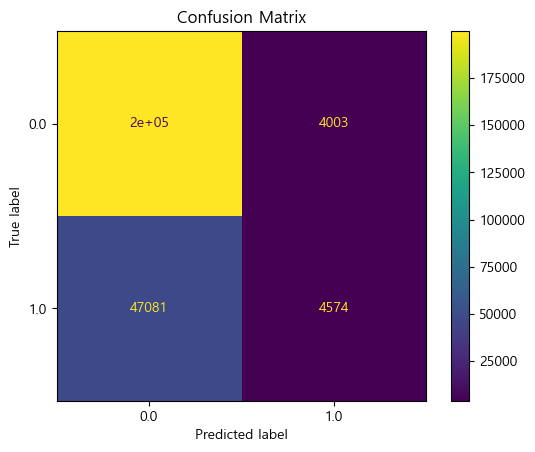

In [22]:
# Positive = 부도

# 혼돈 행렬

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, model.predict(X_test))
print(cm)

# 시각화
ConfusionMatrixDisplay.from_predictions(y_test, model.predict(X_test))
plt.title("Confusion Matrix")
plt.show()

In [24]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

y_pred = model.predict(X_test)
proba  = model.predict_proba(X_test)[:, 1]  # 양성(1) 확률만 담기 
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8001095633119424
              precision    recall  f1-score   support

         0.0       0.81      0.98      0.89    203905
         1.0       0.53      0.09      0.15     51655

    accuracy                           0.80    255560
   macro avg       0.67      0.53      0.52    255560
weighted avg       0.75      0.80      0.74    255560



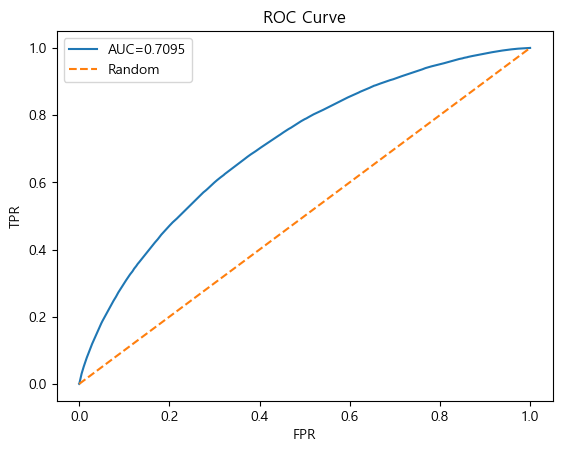

In [ ]:
auc = roc_auc_score(y_test, proba)
fpr, tpr, _ = roc_curve(y_test, proba)

plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
plt.plot([0,1],[0,1], "--", label="Random")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve"); plt.legend(); plt.show()

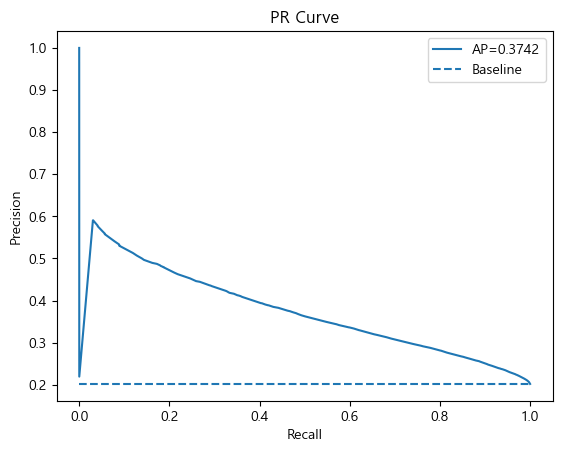

In [ ]:
ap = average_precision_score(y_test, proba)
prec, rec, thresholds = precision_recall_curve(y_test, proba)

plt.plot(rec, prec, label=f"AP={ap:.4f}")
plt.hlines(y_test.mean(), 0, 1, linestyles="--", label="Baseline")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("PR Curve"); plt.legend(); plt.show()
#AP 0.37 → Baseline의 약 1.8배. 랜덤보다는 낫지만 개선 여지가 큼

In [34]:
# 피쳐 중요도
best_model = model
pre = best_model.named_steps["preprocess"]
clf = best_model.named_steps["model"]

importances = clf.feature_importances_

# 피처 이름 가져오기 (num + cat)
num_features = num_cols

ohe = pre.named_transformers_["cat"].named_steps["onehot"]    # OneHotEncoder 객체
cat_features = list(ohe.get_feature_names_out(cat_cols))    # 인코딩된 컬럼 이름

feature_names = list(num_features) + cat_features

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances[:len(feature_names)]
})
fi.sort_values("importance", ascending=False, inplace=True)
print(fi)

                                      feature  importance
1                                    int_rate    0.670766
57                                 issue_year    0.066291
22                                avg_cur_bal    0.062660
60                            term_ 60 months    0.041133
59                            term_ 36 months    0.031211
4                                         dti    0.016861
63                                    grade_C    0.015190
64                                    grade_D    0.014397
114                        emp_length_unknown    0.011783
2                                 installment    0.011224
21                       acc_open_past_24mths    0.009455
118                       home_ownership_RENT    0.007655
3                                  annual_inc    0.006908
38                            num_actv_rev_tl    0.004882
31                                   mort_acc    0.004343
58                                   fico_mid    0.004068
23            

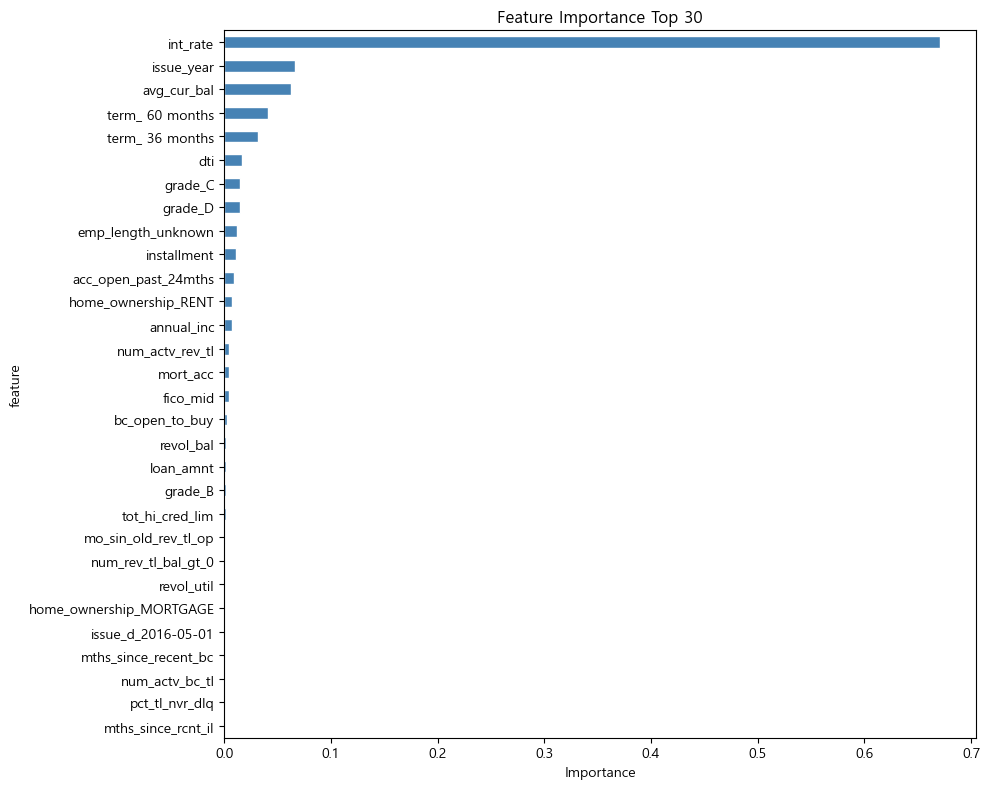

In [33]:
fi.head(30).plot(
    x='feature', y='importance', kind='barh', figsize=(10, 8),
    color='steelblue', edgecolor='white', legend=False
)
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Feature Importance Top 30')
plt.tight_layout()
plt.show()

# 발행 연도말고 발행 월로 계절성 확인 필요 

In [35]:
# 원핫 인코딩 범주 합산


# ── 그룹 컬럼 생성 ──
fi["group"] = fi["feature"].apply(
    lambda x: x.split("_")[0] if "_" in x else x
)

# ── 그룹별 합산 ──
column_importance = (
    fi.groupby("group")["importance"]
      .sum()
      .sort_values(ascending=False)
)

print("\n컬럼별 중요도:")
print(column_importance)


컬럼별 중요도:
group
int             0.670766
term            0.072344
issue           0.067354
avg             0.062660
grade           0.031231
dti             0.016861
emp             0.011783
installment     0.011224
acc             0.009455
home            0.008087
annual          0.006908
num             0.006405
mort            0.004343
fico            0.004068
revol           0.002620
bc              0.002284
tot             0.002119
mths            0.001910
loan            0.001697
mo              0.001298
total           0.001091
earliest        0.001083
addr            0.000682
pct             0.000398
sub             0.000346
delinq          0.000290
open            0.000200
inq             0.000171
purpose         0.000164
application     0.000160
initial         0.000000
collections     0.000000
chargeoff       0.000000
pub             0.000000
percent         0.000000
tax             0.000000
verification    0.000000
Name: importance, dtype: float64
